In [1]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = ['siglip_so400_14', 'siglip_so400_14_384', 'siglip_so400_14_378', 'gemma3_27b','gemma3_4b','chameleon_7b','chameleon_30b', 'paligemma2_10b_mix_224', 'paligemma2_10b_mix_448', 'paligemma2_28b_mix_224', 'paligemma2_28b_mix_448', 'paligemma2_3b_mix_224', 'paligemma2_3b_mix_448', 'paligemma_3b_224', 'paligemma_3b_448', 'paligemma_3b_mix_224', 'paligemma_3b_mix_448']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_27b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/gemma3_4b/sugarcrepe.f
File not found:  /home/haltahan6/unibe

/tmp/ipykernel_1275860/953547125.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


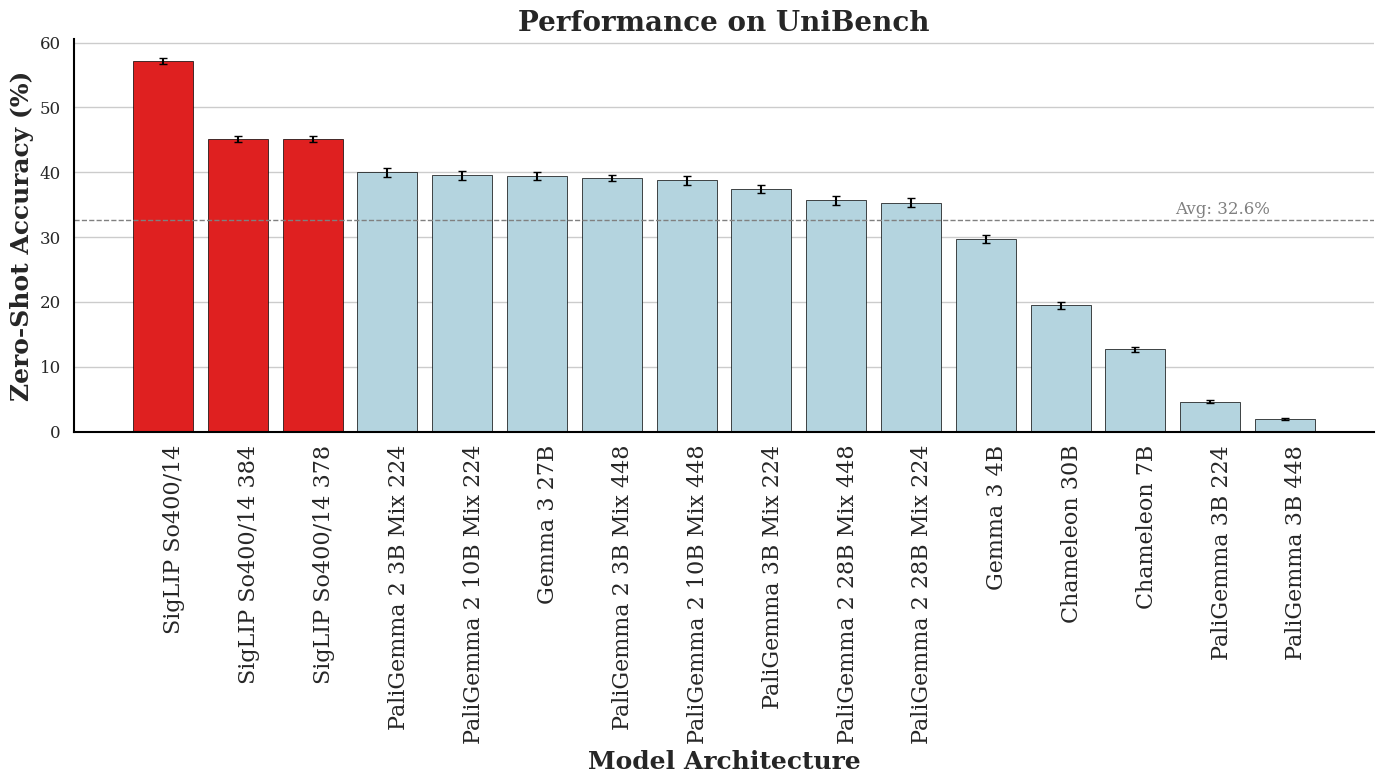

In [14]:
# Compute average and SEM as before
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

model_data = pd.DataFrame({
    'model_name': overall_performance.index,
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Seaborn + matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Create colors: red for SigLIP, light blue for others
colors = ['red' if 'SigLIP' in name else 'lightblue' for name in sorted_models['model_name']]

# Create barplot
ax = sns.barplot(
    data=sorted_models,
    x='model_name',
    y='performance',
    palette=colors,
    edgecolor='black',
    linewidth=0.5,
)

# Add error bars manually
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Customize labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_title('Performance on UniBench', fontsize=TITLE_FONT_SIZE, weight='bold')

# Format x-axis labels
# Current number of bars
num_bars = len(sorted_models)

# Shift each tick to the right by +0.15 units (tweak as needed)
tick_positions = [i + 0.3 for i in range(num_bars)]
tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]

# Apply shifted tick positions and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='right')

# Optional: Add average performance annotation
avg_performance = sorted_models['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(sorted_models) - 1.2, avg_performance + 1,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Despine top/right
sns.despine(trim=False)
plt.tight_layout()

plt.show()


In [9]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = ['clip_vitL14', 'llama_3_2_11b_vision_instruct',
       'llava_1_5_13b', 'llava_1_5_7b', 'llava_1_6_mistral_7b',
       'llava_1_6_vicuna_13b', 'llava_1_6_vicuna_7b',
       'llava_next_llama_8b']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

File not found:  /home/haltahan6/unibench/outputs/llama_3_2_11b_vision_instruct/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_11b_vision_instruct/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_11b_vision_instruct/countbench.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_11b_vision_instruct/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_11b_vision_instruct/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_11b_vision_instruct/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_11b_vision_instruct/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_11b_vision_instruct/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llava_1_5_13b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llava_1_5_13b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/llava_1_5_13b/countbench.f
File not found:  /home/ha

/tmp/ipykernel_1275860/1979274884.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


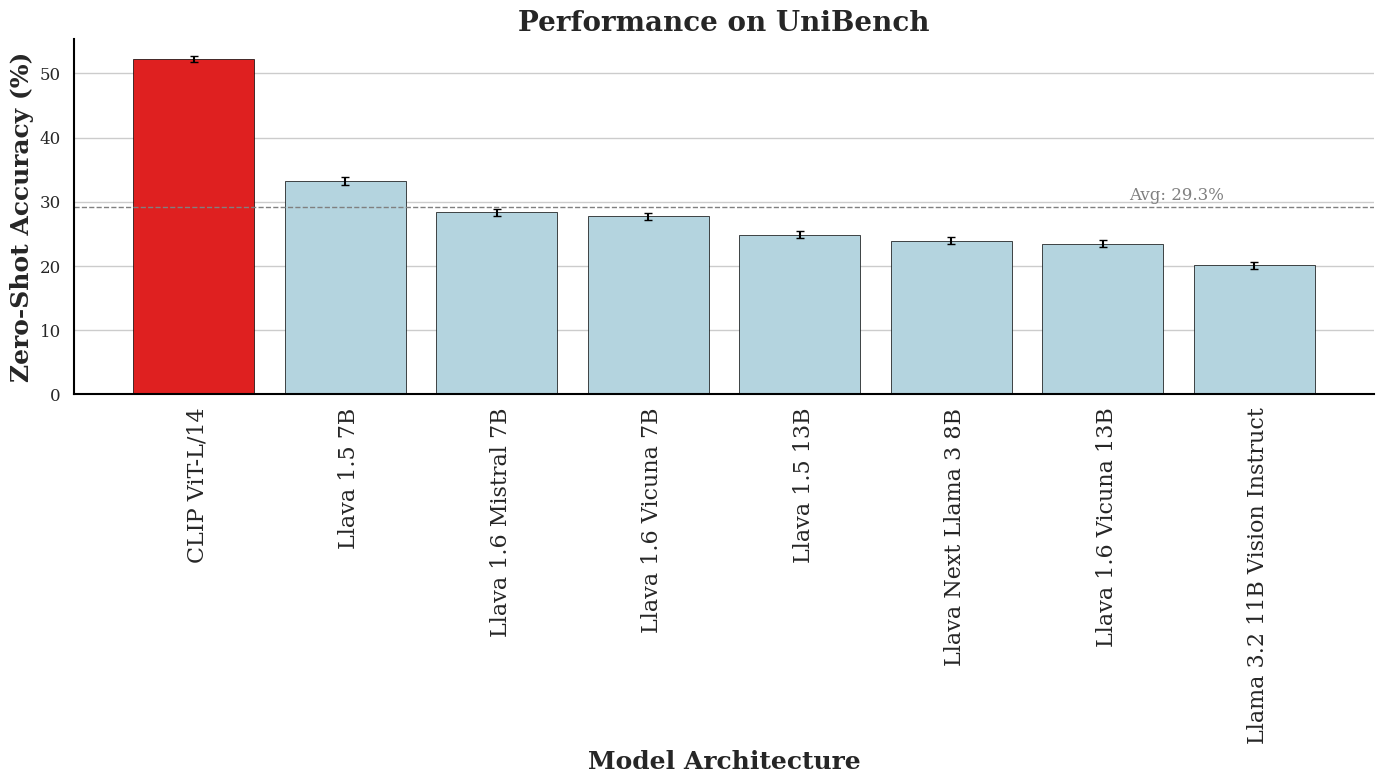

In [12]:
# Compute average and SEM as before
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

model_data = pd.DataFrame({
    'model_name': overall_performance.index,
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Seaborn + matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Create colors: red for SigLIP, light blue for others
colors = ['red' if 'CLIP' in name else 'lightblue' for name in sorted_models['model_name']]

# Create barplot
ax = sns.barplot(
    data=sorted_models,
    x='model_name',
    y='performance',
    palette=colors,
    edgecolor='black',
    linewidth=0.5,
)

# Add error bars manually
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Customize labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_title('Performance on UniBench', fontsize=TITLE_FONT_SIZE, weight='bold')

# Format x-axis labels
# Current number of bars
num_bars = len(sorted_models)

# Shift each tick to the right by +0.15 units (tweak as needed)
tick_positions = [i + 0.1 for i in range(num_bars)]
tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]

# Apply shifted tick positions and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='right')

# Optional: Add average performance annotation
avg_performance = sorted_models['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(sorted_models) - 1.2, avg_performance + 1,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Despine top/right
sns.despine(trim=False)
plt.tight_layout()

plt.show()


In [15]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = ['eva01_vitG14_plus_2b','aya_vision_32b', 'aya_vision_8b']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_32b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/countbench.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/aya_vision_8b

/tmp/ipykernel_1275860/698205941.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


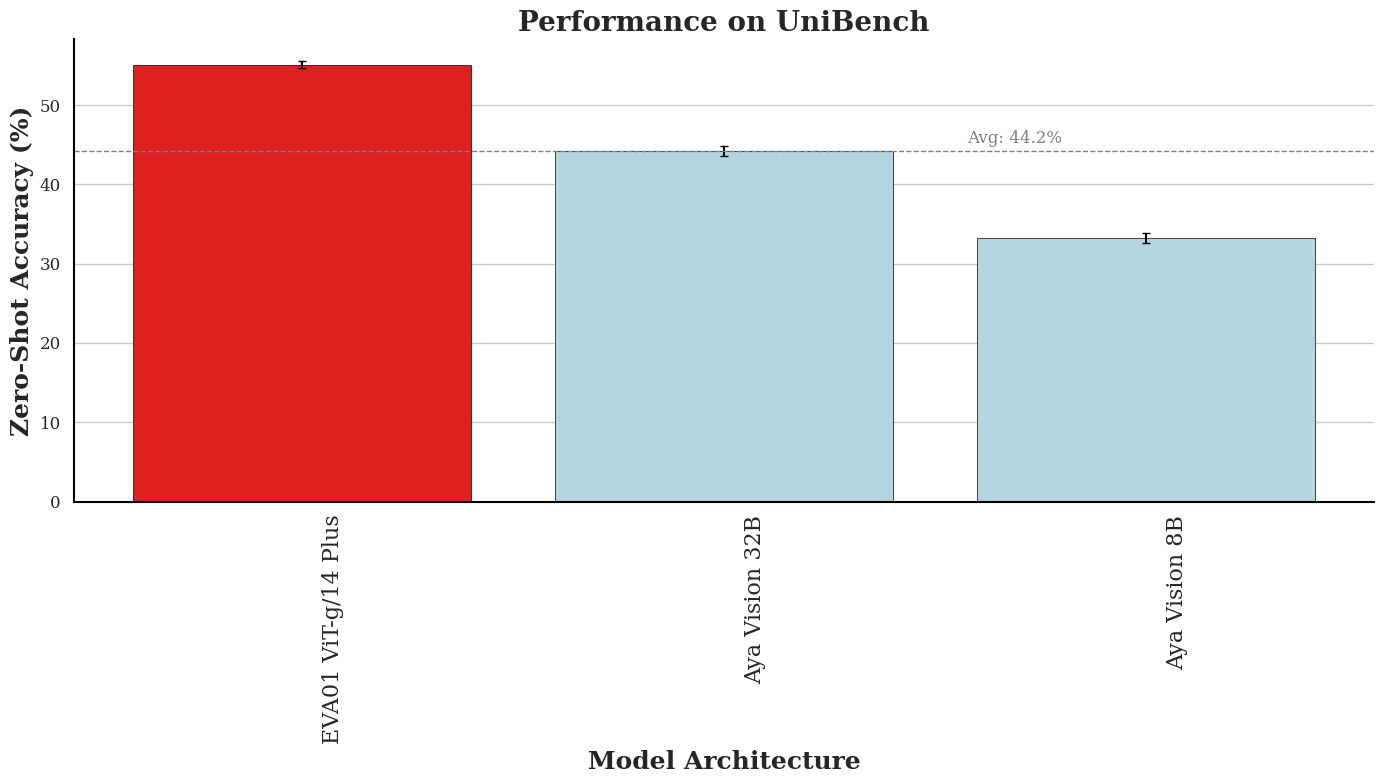

In [17]:
# Compute average and SEM as before
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem()

overall_performance = df_mean.reset_index().groupby("model_name").correctness.mean() * 100
overall_sem = df_sem.reset_index().groupby("model_name").correctness.mean() * 100

model_data = pd.DataFrame({
    'model_name': overall_performance.index,
    'performance': overall_performance.values,
    'sem': overall_sem.values
})

# Sort by performance
sorted_models = model_data.sort_values('performance', ascending=False)

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

# Seaborn + matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Create colors: red for SigLIP, light blue for others
colors = ['red' if 'EVA' in name else 'lightblue' for name in sorted_models['model_name']]

# Create barplot
ax = sns.barplot(
    data=sorted_models,
    x='model_name',
    y='performance',
    palette=colors,
    edgecolor='black',
    linewidth=0.5,
)

# Add error bars manually
for i, row in enumerate(sorted_models.itertuples()):
    plt.errorbar(i, row.performance, yerr=row.sem, fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Customize labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_title('Performance on UniBench', fontsize=TITLE_FONT_SIZE, weight='bold')

# Format x-axis labels
# Current number of bars
num_bars = len(sorted_models)

# Shift each tick to the right by +0.15 units (tweak as needed)
tick_positions = [i + 0.1 for i in range(num_bars)]
tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_models['model_name']]

# Apply shifted tick positions and labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, ha='right')

# Optional: Add average performance annotation
avg_performance = sorted_models['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(sorted_models) - 1.2, avg_performance + 1,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Despine top/right
sns.despine(trim=False)
plt.tight_layout()

plt.show()


In [ ]:
sig_models = ['siglip_so400_14', 'gemma3_27b','gemma3_4b','chameleon_7b','chameleon_30b', 'paligemma2_10b_mix_224', 'paligemma2_10b_mix_448', 'paligemma2_28b_mix_224', 'paligemma2_28b_mix_448', 'paligemma2_3b_mix_224', 'paligemma2_3b_mix_448', 'paligemma_3b_224', 'paligemma_3b_448', 'paligemma_3b_mix_224', 'paligemma_3b_mix_448']
clip_models = ['clip_vitL14', 'llama_3_2_11b_vision_instruct',
       'llava_1_5_13b', 'llava_1_5_7b', 'llava_1_6_mistral_7b',
       'llava_1_6_vicuna_13b', 'llava_1_6_vicuna_7b',
       'llava_next_llama_8b']
eva_models = ['eva01_vitG14_plus_2b','aya_vision_32b', 'aya_vision_8b']

import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list(set(sig_models + clip_models + eva_models))

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)



File not found:  /home/haltahan6/unibench/outputs/paligemma2_10b_mix_224/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_10b_mix_224/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_10b_mix_224/countbench.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_10b_mix_224/flickr30k_order.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_10b_mix_224/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_10b_mix_224/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_10b_mix_224/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_10b_mix_224/winoground.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_28b_mix_448/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_28b_mix_448/coco_order.f
File not found:  /home/haltahan6/unibench/outputs/paligemma2_28b_mix_448/countbench.f
File not found:  /home/haltahan6/unibench/outputs/pali

In [21]:
results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
sig_results = results[results['model_name'].isin(sig_models)]
clip_results = results[results['model_name'].isin(clip_models)]
eva_results = results[results['model_name'].isin(eva_models)]

from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

In [28]:
# Calculate performance for each category
def calculate_performance_diff(category_results, reference_model_key, category_models):
    if len(category_results) == 0:
        return pd.DataFrame()
    
    # Calculate mean performance for each model using original model names
    performance = category_results.groupby("model_name").correctness.mean() * 100
    
    # Get reference performance using original model name
    if reference_model_key in performance.index:
        reference_perf = performance[reference_model_key]
        
        # Calculate differences
        differences = performance - reference_perf
        
        # Map to display names for output
        mapped_names = [model_mappings.get(name, name) for name in differences.index]
        
        return pd.DataFrame({
            'model_name': mapped_names,
            'performance': performance.values,
            'difference_from_reference': differences.values,
            'category': [reference_model_key.split('_')[0].upper()] * len(differences)
        })
    else:
        return pd.DataFrame()

# Calculate differences for each category
sig_diff = calculate_performance_diff(sig_results, sig_models[0], sig_models)
clip_diff = calculate_performance_diff(clip_results, clip_models[0], clip_models) 
eva_diff = calculate_performance_diff(eva_results, eva_models[0], eva_models)

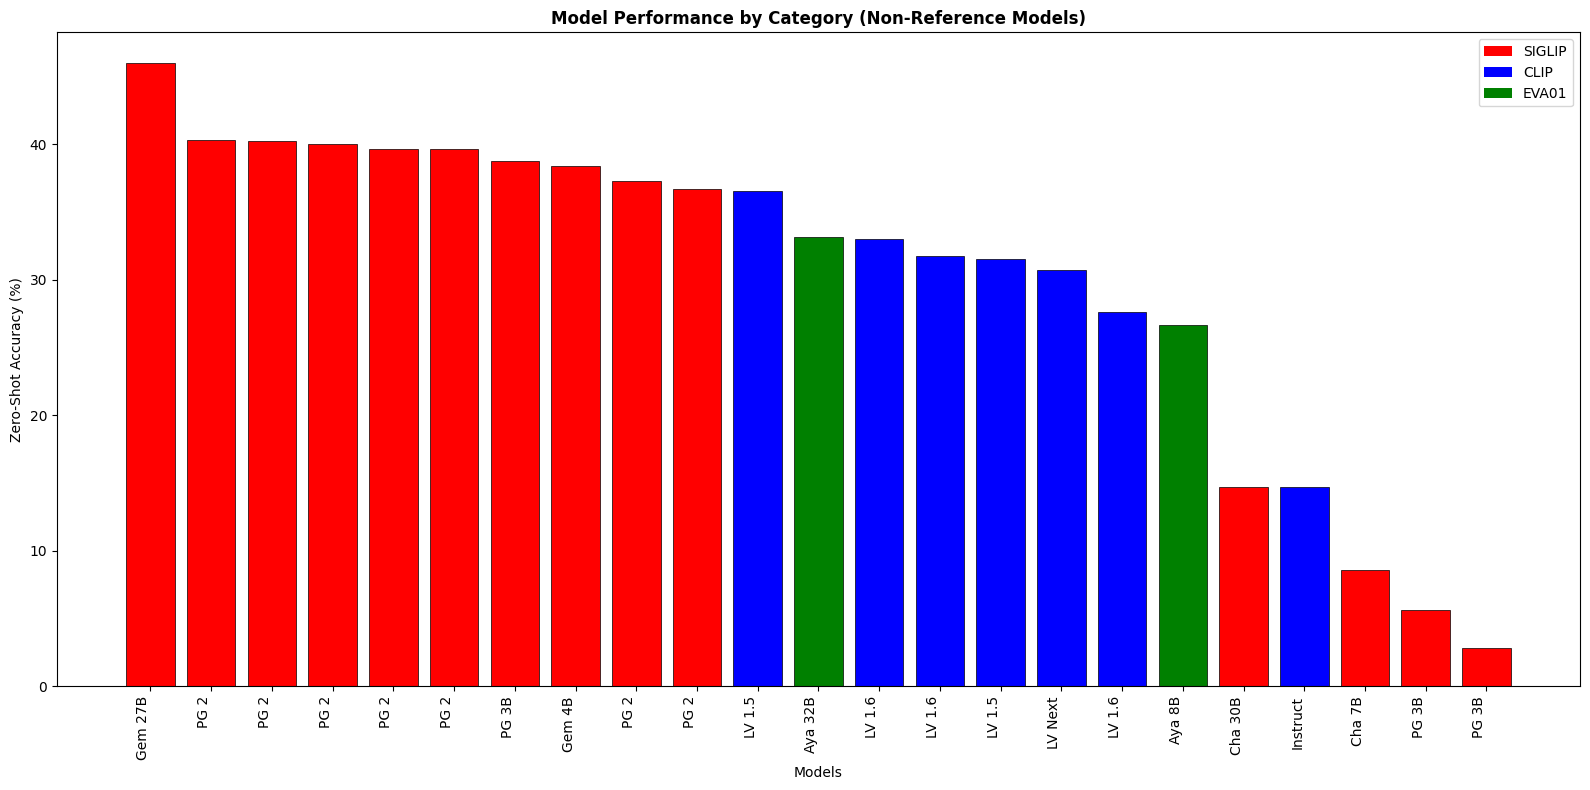

Performance Summary by Category (Non-Reference Models):

SIGLIP:
  Best performing: Gemma 3 27B (46.0%)
  Average performance: 30.6%
  Number of models: 14

CLIP:
  Best performing: Llava 1.5 7B (36.6%)
  Average performance: 29.4%
  Number of models: 7

EVA01:
  Best performing: Aya Vision 32B (33.1%)
  Average performance: 29.9%
  Number of models: 2


In [33]:
from matplotlib.patches import Patch

# Create a single plot showing absolute performance
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Combine all differences into one dataframe
all_diffs = pd.concat([sig_diff, clip_diff, eva_diff], ignore_index=True)

# Remove reference models (those with difference_from_reference = 0)
non_reference_data = all_diffs[all_diffs['difference_from_reference'] != 0]

# Sort by performance for better visualization
sorted_data = non_reference_data.sort_values('performance', ascending=False)

# Define colors for each category
colors_dict = {'SIGLIP': 'red', 'CLIP': 'blue', 'EVA01': 'green'}
model_colors = [colors_dict[cat] for cat in sorted_data['category']]

# Plot: Absolute Performance
bars = ax.bar(range(len(sorted_data)), sorted_data['performance'], 
               color=model_colors, edgecolor='black', linewidth=0.5)

ax.set_title('Model Performance by Category (Non-Reference Models)', weight='bold')
ax.set_ylabel('Zero-Shot Accuracy (%)')
ax.set_xlabel('Models')

# Simplify x-axis labels
simplified_names = []
for name in sorted_data['model_name']:
    if 'PaliGemma' in name:
        parts = name.split()
        if len(parts) >= 2:
            simplified_names.append(f"PG {parts[1]}")
        else:
            simplified_names.append(name[:10])
    elif 'Llava' in name:
        parts = name.split()
        if len(parts) >= 2:
            simplified_names.append(f"LV {parts[1]}")
        else:
            simplified_names.append(name[:10])
    elif 'Chameleon' in name or 'Gemma' in name or 'Aya' in name:
        parts = name.split()
        if len(parts) >= 2:
            simplified_names.append(f"{parts[0][:3]} {parts[-1]}")
        else:
            simplified_names.append(name[:10])
    else:
        simplified_names.append(name.split()[-1] if ' ' in name else name[:12])

ax.set_xticks(range(len(sorted_data)))
ax.set_xticklabels(simplified_names, rotation=90, ha='right')

# Add legend
categories = sorted_data['category'].unique()
legend_elements = [Patch(facecolor=colors_dict[cat], label=cat) for cat in categories]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Performance Summary by Category (Non-Reference Models):")
for category in categories:
    cat_data = sorted_data[sorted_data['category'] == category]
    if len(cat_data) > 0:
        print(f"\n{category}:")
        print(f"  Best performing: {cat_data.loc[cat_data['performance'].idxmax(), 'model_name']} ({cat_data['performance'].max():.1f}%)")
        print(f"  Average performance: {cat_data['performance'].mean():.1f}%")
        print(f"  Number of models: {len(cat_data)}")
